# Notebook 4: EDA — Análisis A (regional por piso ecológico)

**Objetivo**: explorar el dataset agregado por piso ecológico para entender:
- Volúmenes y estacionalidad de producción por unidad regional (14 unidades)
- Características climáticas de cada piso ecológico
- Tendencias temporales y eventos extremos
- Primera mirada a correlaciones clima-producción a nivel agregado

**Input**: `dataset_regional.csv` del notebook 3.

**Estructura**:
1. Configuración y carga
2. Exploración de la producción (volúmenes, estacionalidad, tendencias)
3. Exploración del clima por piso
4. Detección del evento de sequía 2022-2023 en Puno
5. Correlaciones clima-producción agregadas
6. Conclusiones y notas para el informe

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
pd.set_option('display.max_columns', 25)

## 1. Carga del dataset

In [95]:
# >>>>>>>>>>> AJUSTAR ESTA RUTA <<<<<<<<<<<
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "SCRIPTS":
    ROOT = ROOT.parent

RUTA_OUTPUT = ROOT / "OUTPUTS"
RUTA_BASE = ROOT / "Datasets Originales"
RUTA_OUTPUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RUTA_OUTPUT / "dataset_regional.csv")

# Compatibilidad: datasets exportados con nombres legibles
_RENAME = {
    "piso_ecologico": "piso",
    "numero_mes": "mes_num",
    "mes": "mes_nombre",
    "produccion_piso_ton": "produccion_total_piso",
    "num_cultivos": "n_cultivos",
    "temp_promedio": "t2m", "temp_maxima": "t2m_max", "temp_minima": "t2m_min",
    "precipitacion": "prectotcorr", "humedad_relativa": "rh2m",
    "radiacion_solar": "allsky_sfc_sw_dwn", "velocidad_viento": "ws2m",
    "presion_atmosferica": "ps", "humedad_suelo": "gwetroot",
    "temp_superficie": "ts", "punto_rocio": "t2mdew", "humedad_especifica": "qv2m",
}
for nuevo, viejo in _RENAME.items():
    if nuevo in df.columns and viejo not in df.columns:
        df = df.rename(columns={nuevo: viejo})

df_b = pd.read_csv(RUTA_OUTPUT / "dataset_por_cultivo.csv")
_RENAME_B = {**_RENAME, "piso_ecologico": "piso_asignado", "produccion_ton": "produccion_mensual"}
for nuevo, viejo in _RENAME_B.items():
    if nuevo in df_b.columns and viejo not in df_b.columns:
        df_b = df_b.rename(columns={nuevo: viejo})

# Crear etiqueta unidad para visualizaciones (region + piso)
df['unidad'] = df['region'] + ' - ' + df['piso']

# Crear fecha (primer día del mes) para series temporales
df['fecha'] = pd.to_datetime(dict(year=df['anio'], month=df['mes_num'], day=1))

print(f"Dataset: {df.shape}")
print(f"Periodo: {df['fecha'].min().strftime('%Y-%m')} a {df['fecha'].max().strftime('%Y-%m')}")
print(f"\nUnidades regionales ({df['unidad'].nunique()}):")
for u in sorted(df['unidad'].unique()):
    print(f"  - {u}")
print(f"\nMuestra:")
print(df.head(3))

Dataset: (1008, 22)
Periodo: 2020-01 a 2025-12

Unidades regionales (14):
  - Ica - costa
  - Junin - selva_alta
  - Junin - selva_baja
  - Junin - sierra
  - La Libertad - costa
  - La Libertad - sierra
  - La Libertad - yunga
  - Piura - bosque_seco
  - Piura - sierra
  - Piura - valle_chira
  - Puno - altiplano_lacustre
  - Puno - puna_alta
  - San Martin - selva_alto_mayo
  - San Martin - selva_huallaga

Muestra:
  region   piso      distrito  anio  mes_num mes_nombre  n_cultivos  \
0    Ica  costa  Chincha Alta  2020        1      Enero          30   
1    Ica  costa  Chincha Alta  2020        2    Febrero          30   
2    Ica  costa  Chincha Alta  2020        3      Marzo          30   

   produccion_total_piso    t2m  t2m_max  t2m_min  prectotcorr   rh2m  \
0             183140.759  21.96    27.55    18.21         0.12  78.45   
1             127806.348  22.85    27.98    19.51         0.16  79.22   
2             106005.489  22.62    27.86    19.17         0.20  78.16   

 

In [96]:
# Mapeo de códigos NASA POWER a etiquetas legibles
LABELS_CLIMA = {
    't2m': 'Temp. promedio (°C)',
    't2m_max': 'Temp. máxima (°C)',
    't2m_min': 'Temp. mínima (°C)',
    'prectotcorr': 'Precipitación (mm/día)',
    'rh2m': 'Humedad relativa (%)',
    'gwetroot': 'Humedad del suelo',
    'allsky_sfc_sw_dwn': 'Radiación solar (W/m²)',
    'ws2m': 'Velocidad viento (m/s)',
    'ps': 'Presión atmosférica (kPa)',
    'ts': 'Temp. superficie suelo (°C)',
    't2mdew': 'Punto de rocío (°C)',
    'qv2m': 'Humedad específica (g/kg)',
}

## 2. Producción agregada por unidad regional

### 2.1 Volumen total por unidad (los 6 años acumulados)

Ranking de las 14 unidades por volumen total. Sirve para ubicar quién mueve más toneladas en general.

Producción total 2020-2025 por unidad regional:
     region               piso     distrito  millones_tn
La Libertad              costa         Viru        36.84
       Puno          puna_alta      Ayaviri        20.36
       Puno altiplano_lacustre        Ilave        10.19
        Ica              costa Chincha Alta         9.32
 San Martin    selva_alto_mayo    Moyobamba         7.71
      Piura        valle_chira      Sullana         6.82
      Junin         selva_alta       Perene         6.39
 San Martin     selva_huallaga      Tocache         5.78
      Junin             sierra     El Tambo         5.35
La Libertad             sierra   Huamachuco         4.46
      Piura        bosque_seco  Tambogrande         2.81
      Junin         selva_baja    Rio Tambo         1.08
      Piura             sierra    Canchaque         0.50
La Libertad              yunga       Cascas         0.36


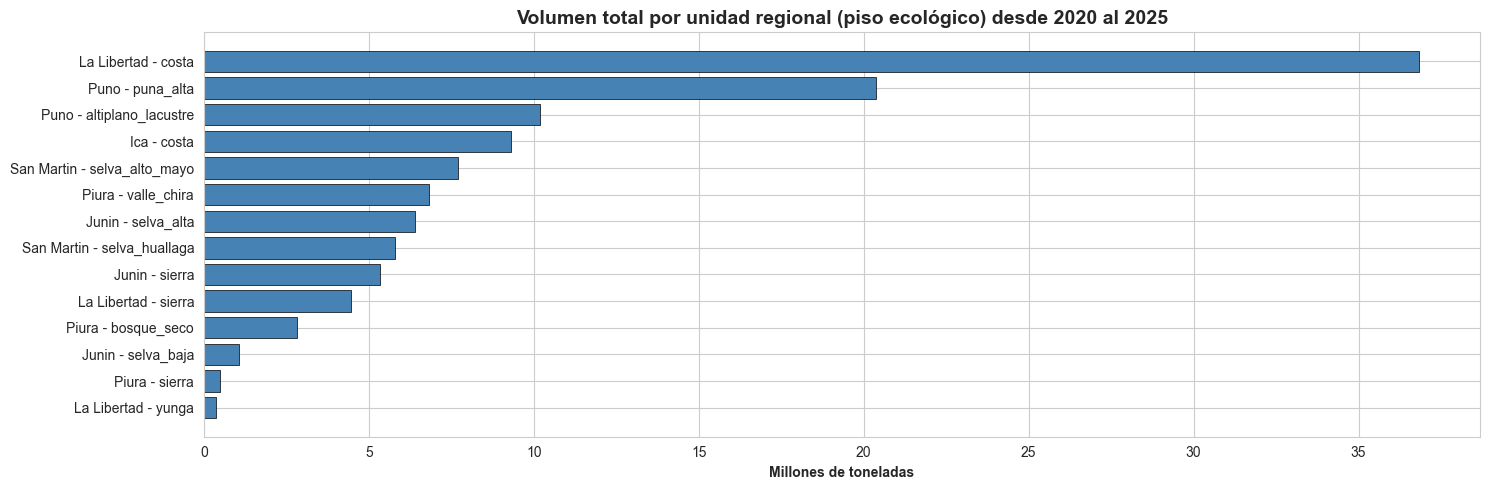

In [98]:
vol_total = (df.groupby(['region','piso','distrito'])['produccion_total_piso']
             .sum().sort_values(ascending=False).reset_index())
vol_total['millones_tn'] = (vol_total['produccion_total_piso'] / 1e6).round(2)

print("Producción total 2020-2025 por unidad regional:")
print(vol_total[['region','piso','distrito','millones_tn']].to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(15, 5))
vol_plot = vol_total.copy()
vol_plot['unidad'] = vol_plot['region'] + ' - ' + vol_plot['piso']
ax.barh(vol_plot['unidad'], vol_plot['millones_tn'], color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Millones de toneladas', fontsize=10, fontweight='bold')
ax.set_title('Volumen total por unidad regional (piso ecológico) desde 2020 al 2025', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 2.2 Series temporales de producción

Una línea por unidad regional. Para que sea legible, separamos por región (cada región tiene 1-3 pisos).

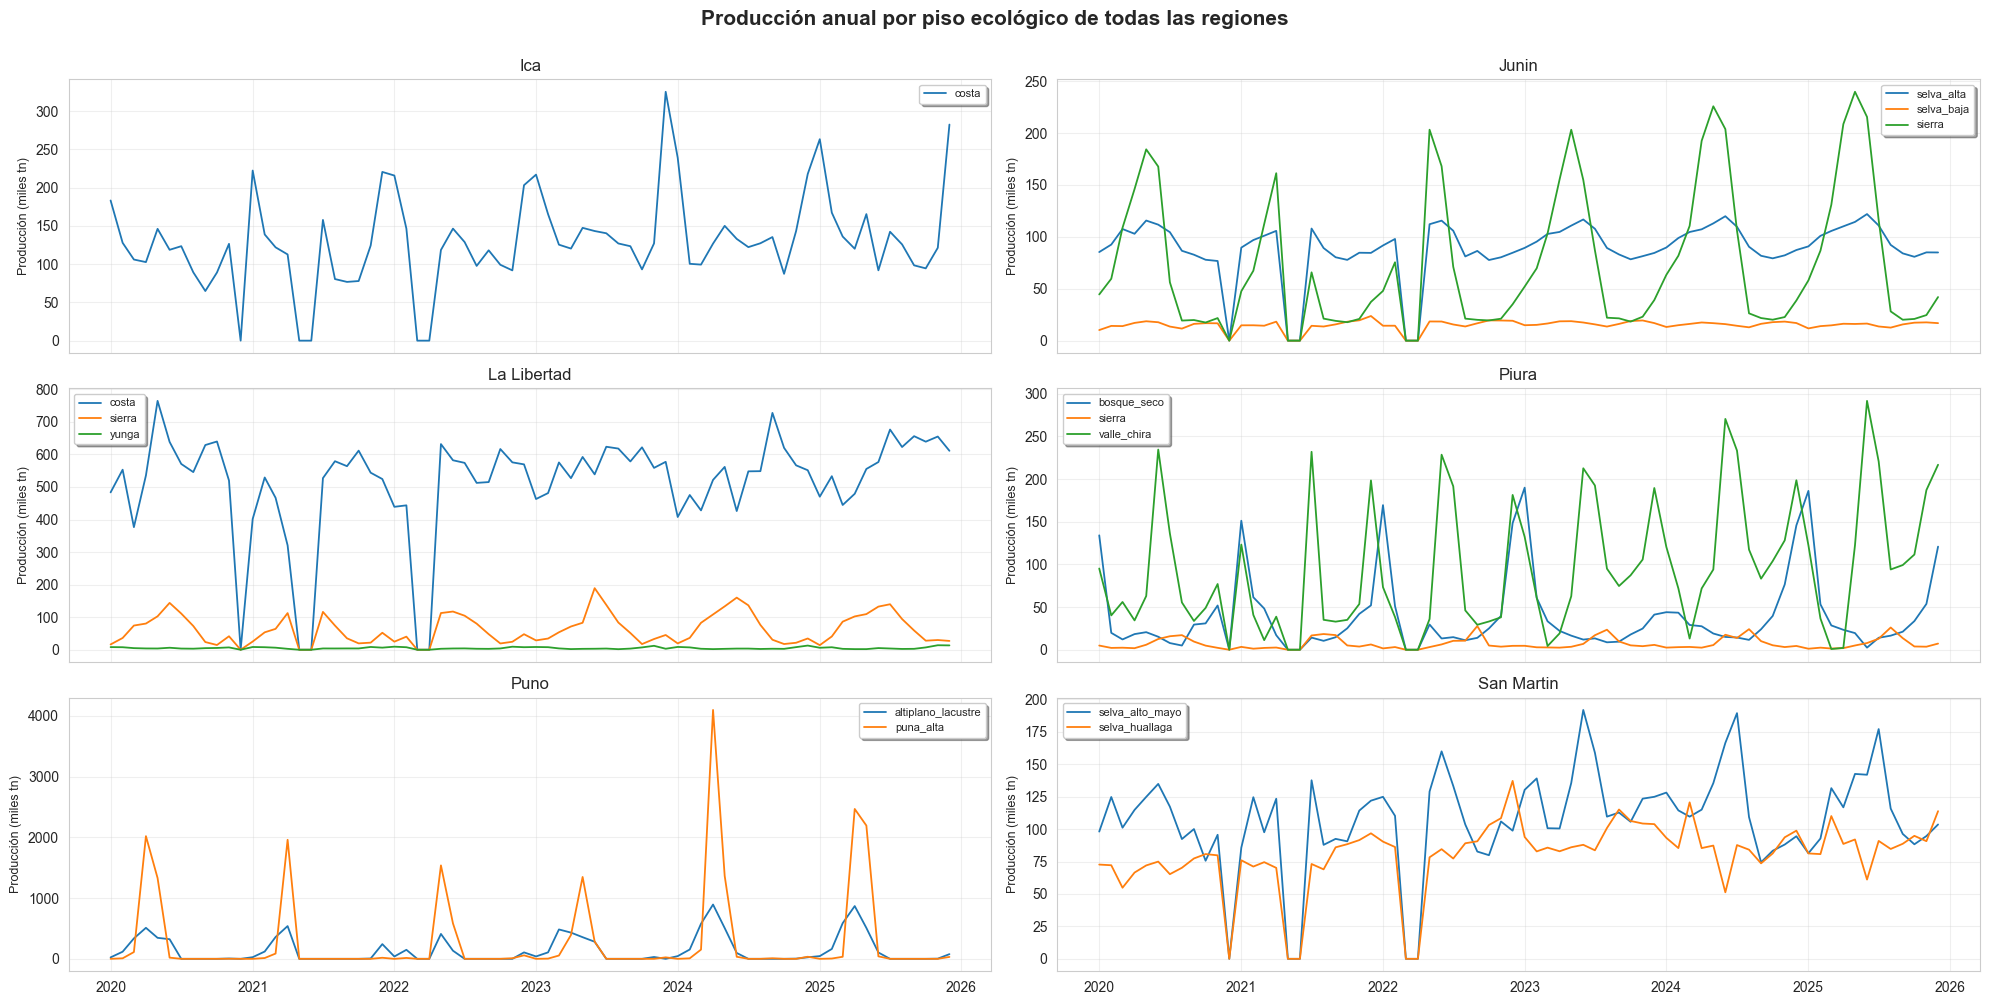

In [99]:
regiones = sorted(df['region'].unique())

fig, axes = plt.subplots(3, 2, figsize=(20, 10), sharex=True)
axes = axes.flatten()

for i, region in enumerate(regiones):
    ax = axes[i]
    sub = df[df['region']==region]
    for piso in sorted(sub['piso'].unique()):
        s = sub[sub['piso']==piso].sort_values('fecha')
        ax.plot(s['fecha'], s['produccion_total_piso']/1000, label=piso, linewidth=1.3)
    ax.set_title(region, fontsize=12)
    ax.set_ylabel('Producción (miles tn)', fontsize=9)
    ax.legend(fontsize=8, loc='best', shadow=True)
    ax.grid(True, alpha=0.3)

plt.suptitle('Producción anual por piso ecológico de todas las regiones', y=1.0, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Estacionalidad (heatmap mes × año)

Para detectar patrones estacionales claros. Cada celda es un mes. Los colores muestran intensidad de producción.

Hago un heatmap por unidad regional. Este es el gráfico más rico del EDA — vas a ver claramente las temporadas de cosecha.

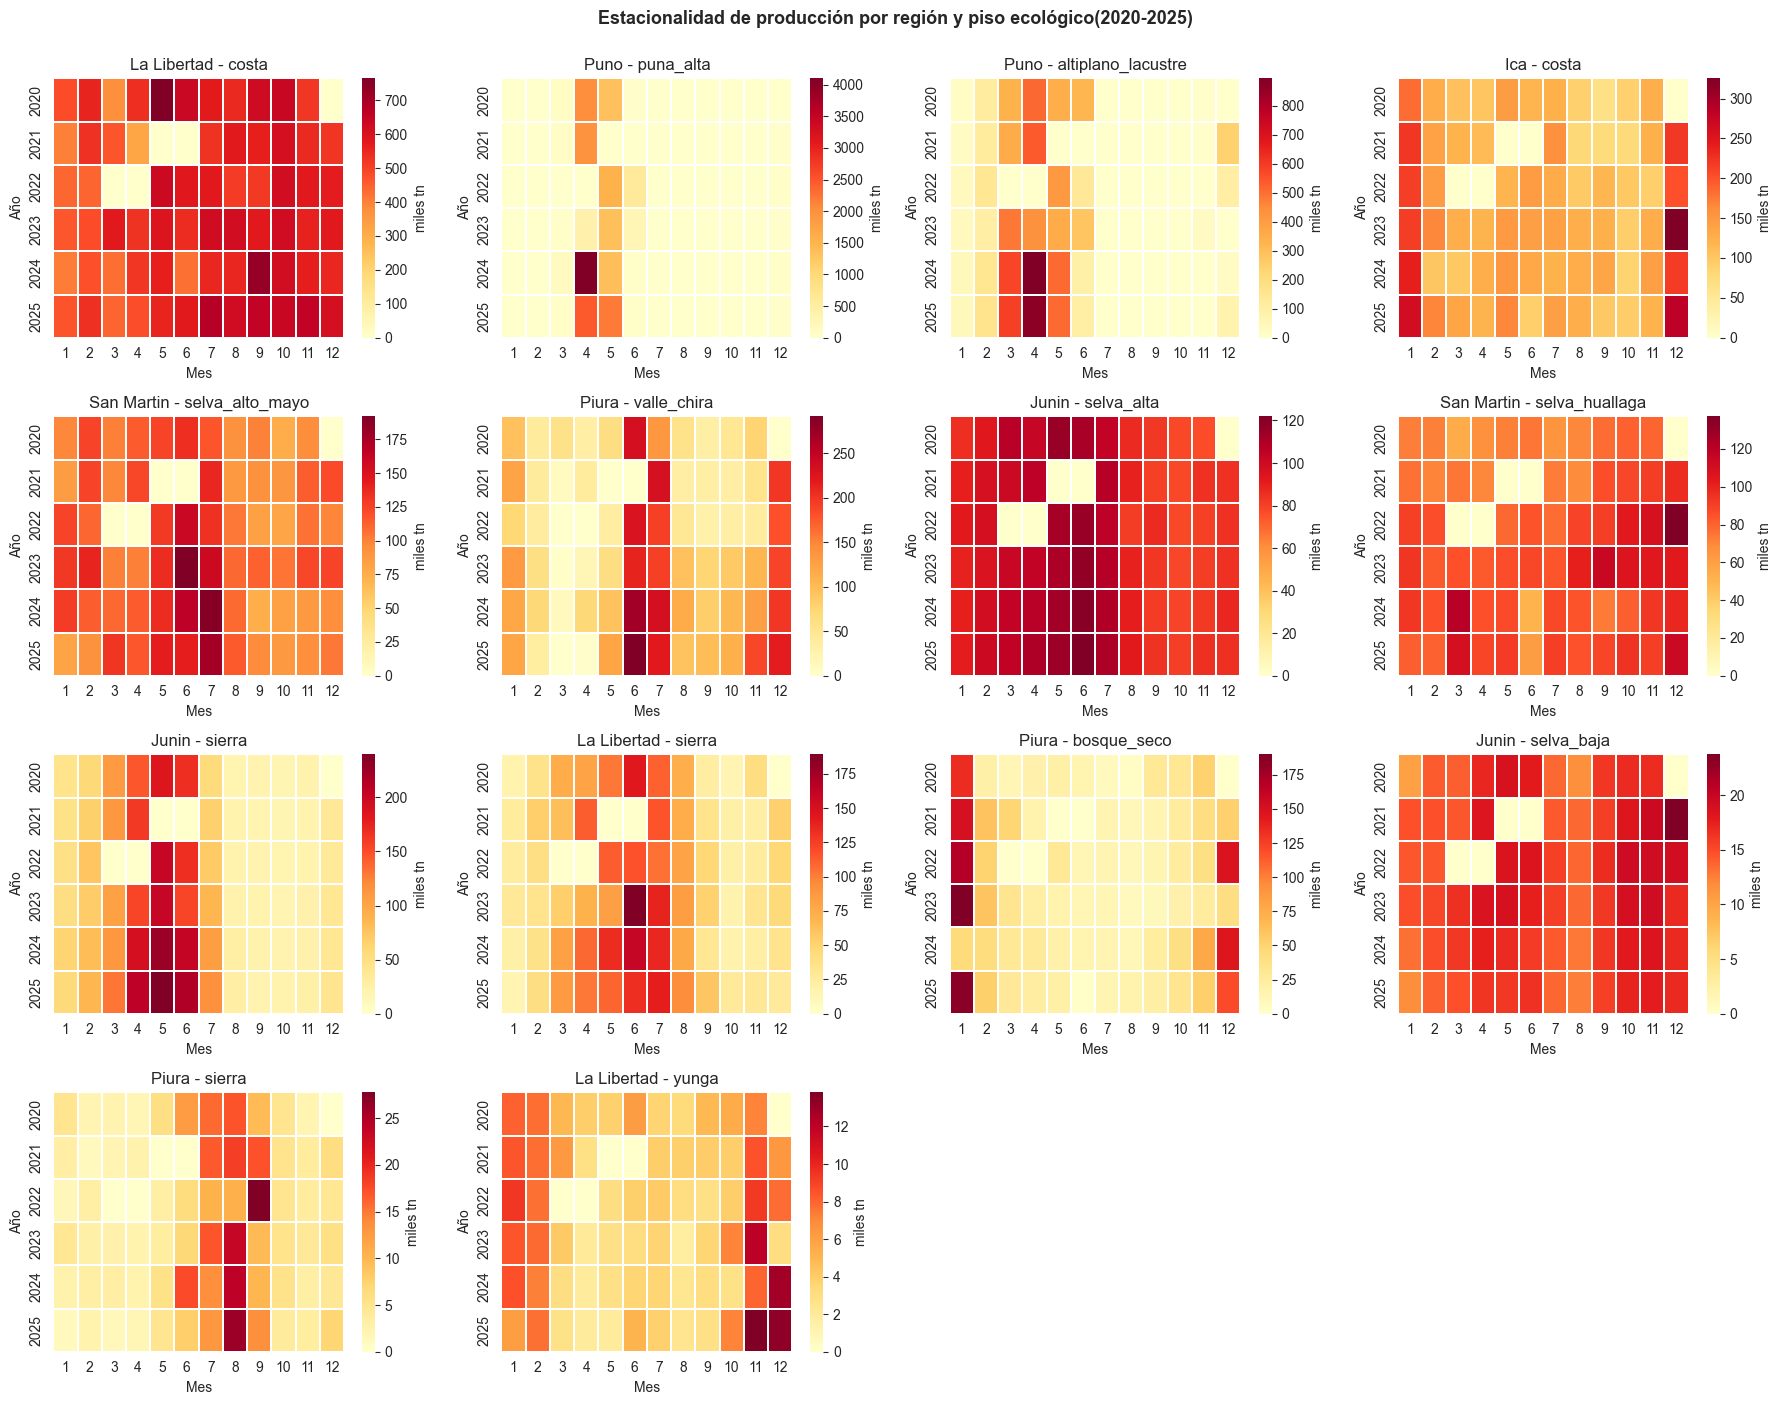

In [109]:
# Pivote: mes en x, año en y, valor = producción
def heatmap_unidad(df, region, piso, ax):
    sub = df[(df['region']==region) & (df['piso']==piso)]
    pivot = sub.pivot_table(index='anio', columns='mes_num', values='produccion_total_piso')
    sns.heatmap(pivot/1000, ax=ax, cmap='YlOrRd', cbar_kws={'label':'miles tn'}, 
                annot=False, fmt='.0f', linewidths=0.3)
    ax.set_title(f'{region} - {piso}', fontsize=12)
    ax.set_xlabel('Mes', fontsize=10)
    ax.set_ylabel('Año', fontsize=10)

# Crear grid de heatmaps (14 unidades = 4 filas × 4 cols, dejando 2 vacíos)
unidades_lista = (df.groupby(['region','piso'])['produccion_total_piso']
                  .sum().sort_values(ascending=False).reset_index())

n_unidades = len(unidades_lista)
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, row in unidades_lista.iterrows():
    heatmap_unidad(df, row['region'], row['piso'], axes[i])

# Ocultar ejes vacíos
for j in range(n_unidades, len(axes)):
    axes[j].axis('off')

plt.suptitle('Estacionalidad de producción por región y piso ecológico(2020-2025)', 
             fontsize=13, y=1.0, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Patrón estacional promedio

Producción promedio por mes (promediando los 6 años). Te muestra **la firma estacional** de cada unidad.

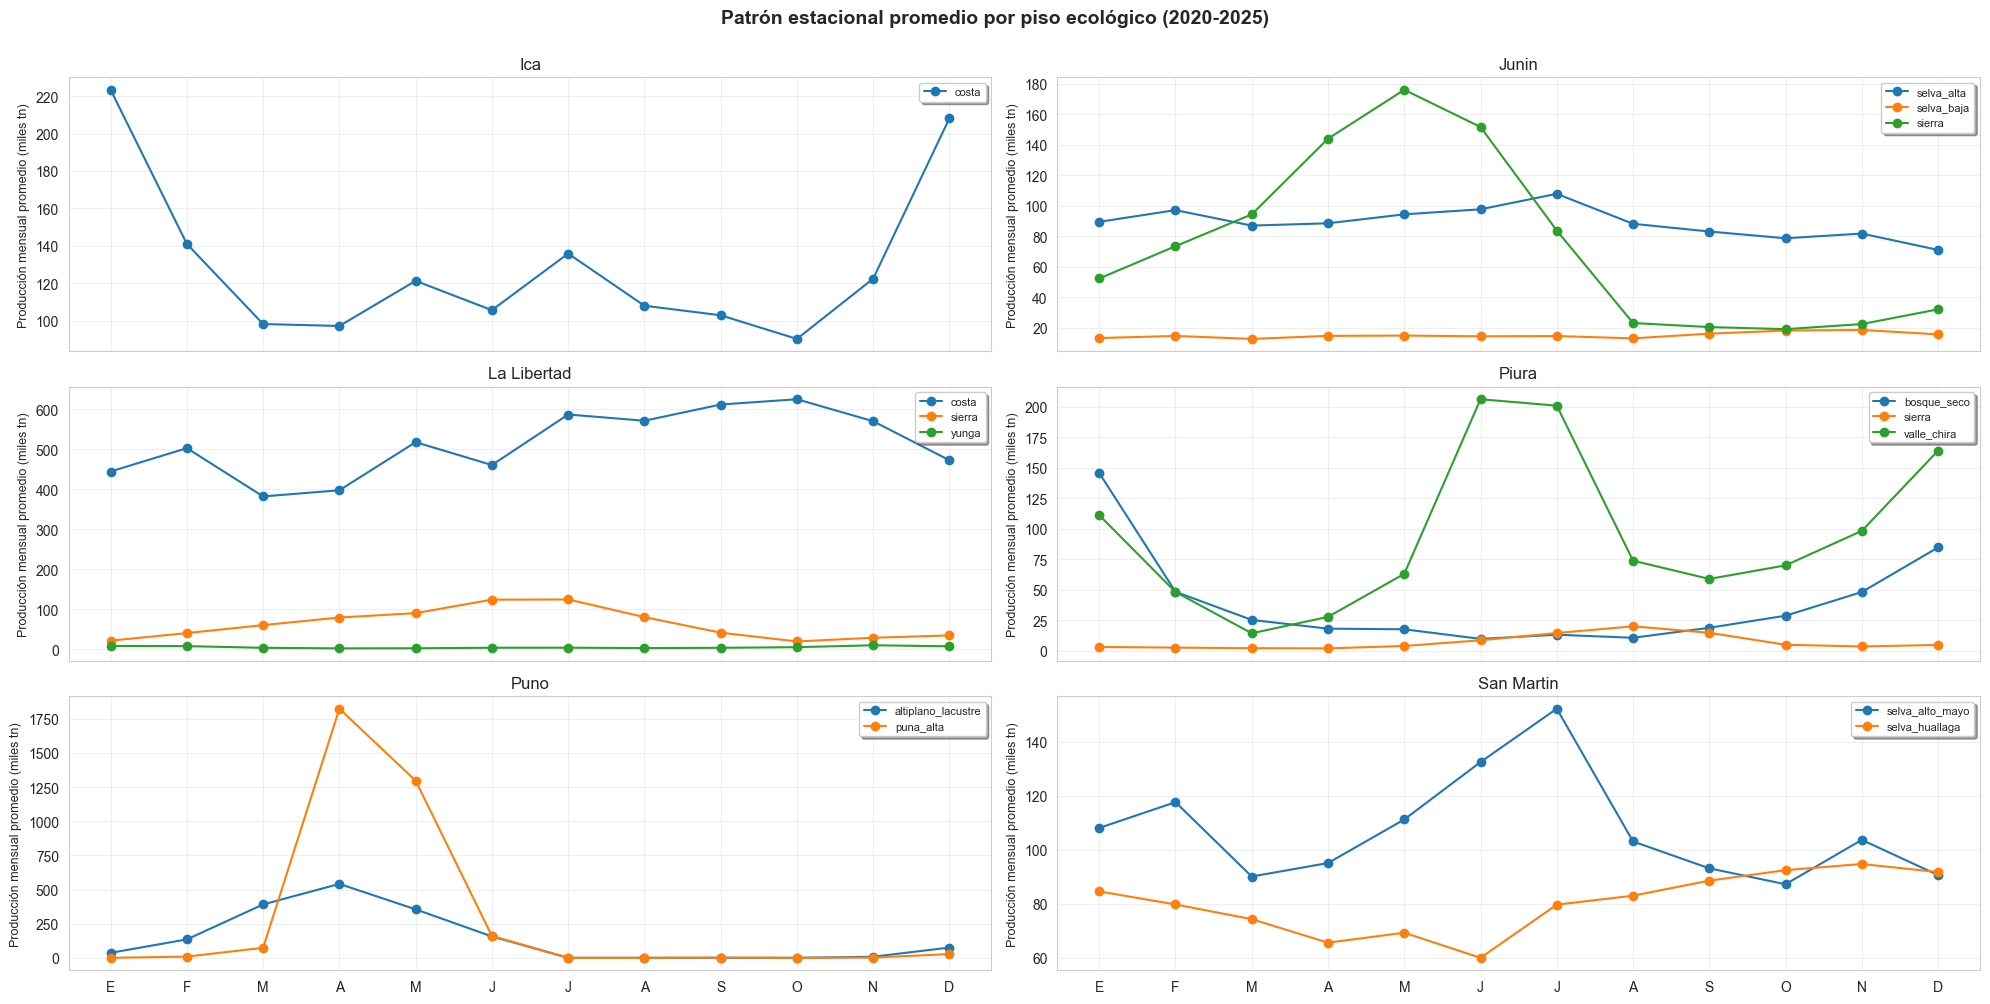

In [101]:
fig, axes = plt.subplots(3, 2, figsize=(20, 10), sharex=True)
axes = axes.flatten()

for i, region in enumerate(regiones):
    ax = axes[i]
    sub = df[df['region']==region]
    for piso in sorted(sub['piso'].unique()):
        prom = (sub[sub['piso']==piso].groupby('mes_num')['produccion_total_piso']
                .mean()/1000)
        ax.plot(prom.index, prom.values, marker='o', label=piso, linewidth=1.5)
    ax.set_title(region, fontsize=12)
    ax.set_ylabel('Producción mensual promedio (miles tn)', fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['E','F','M','A','M','J','J','A','S','O','N','D'], fontsize=10)
    ax.legend(fontsize=8, shadow=True)
    ax.grid(True, alpha=0.3)

plt.suptitle('Patrón estacional promedio por piso ecológico (2020-2025)', y=1.0, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

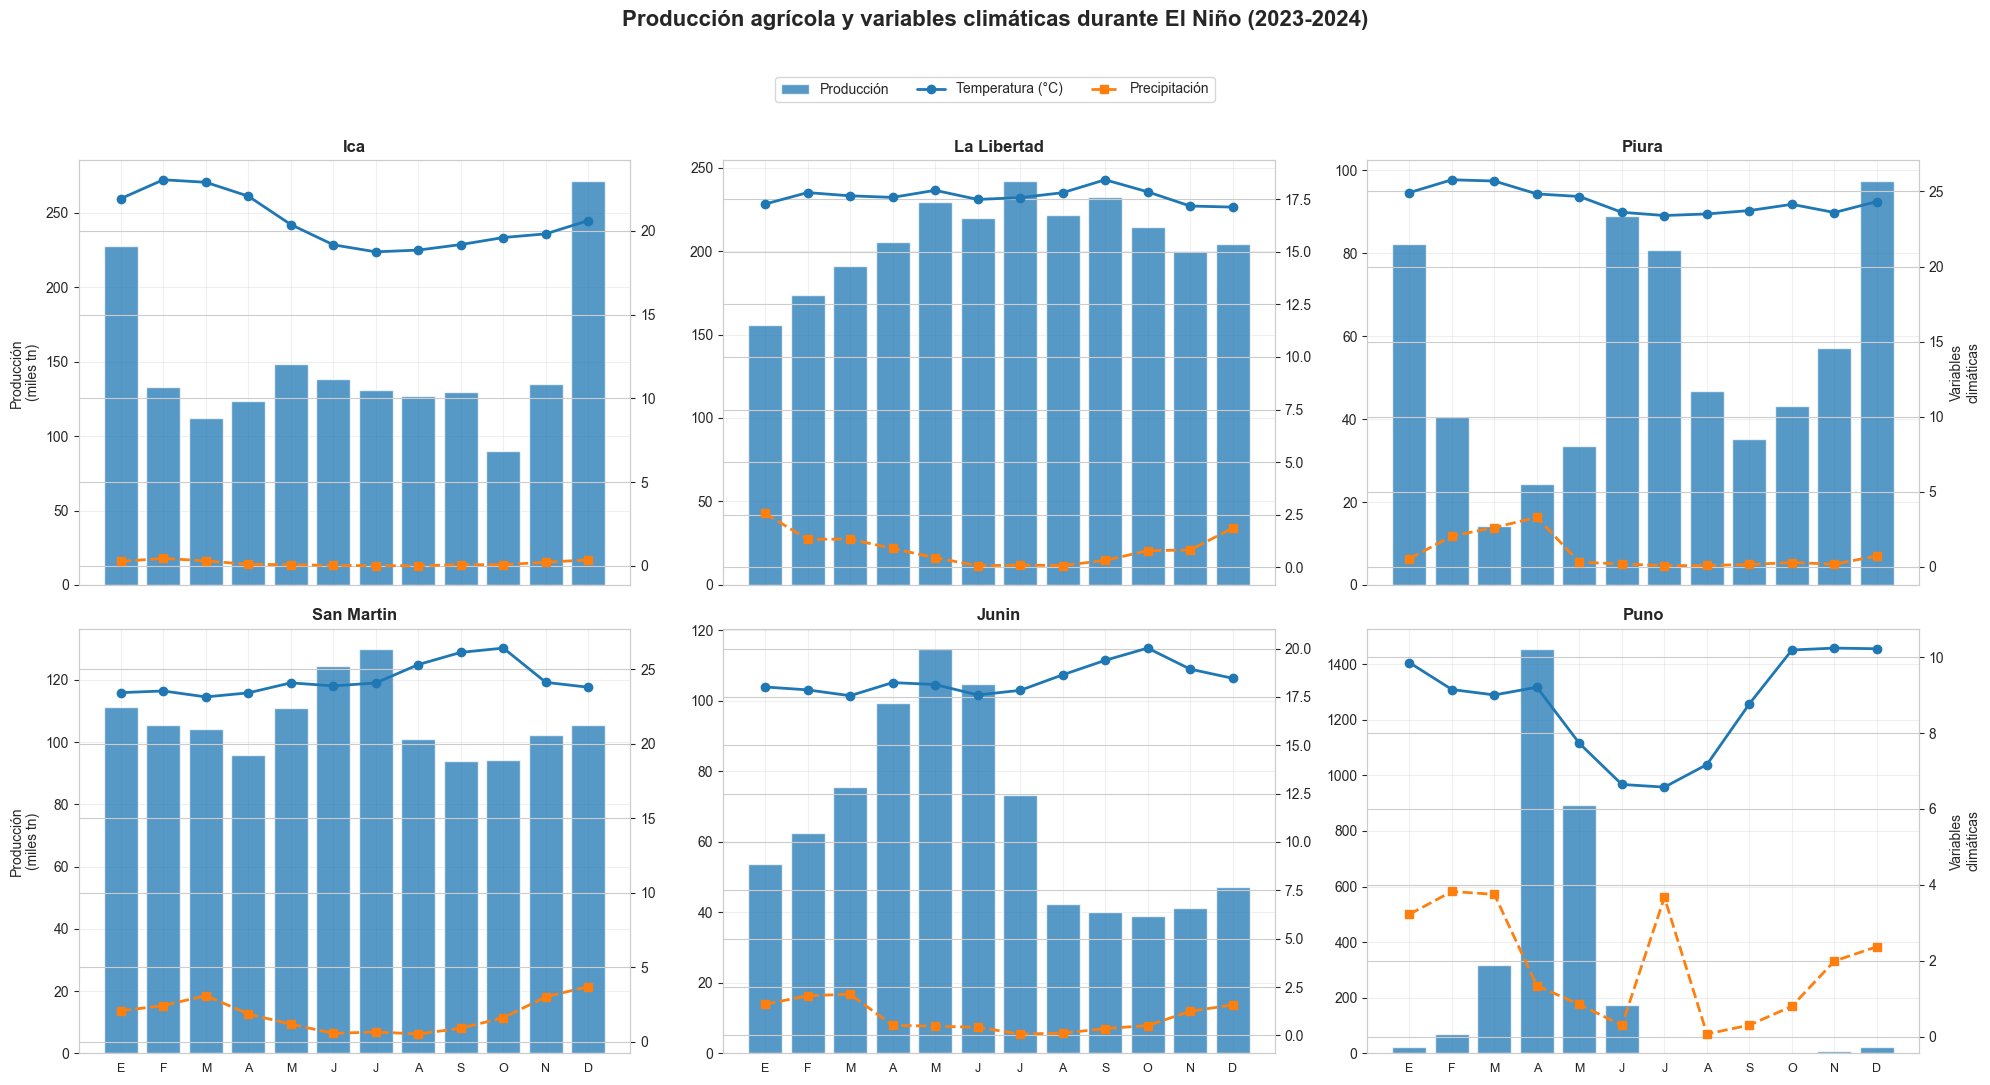

In [120]:
# =========================================================
# FILTRAR SOLO 2023-2024
# =========================================================

df_nino = df[df['anio'].isin([2023, 2024])].copy()

# =========================================================
# ORDEN DE REGIONES
# =========================================================

regiones = [
    'Ica',
    'La Libertad',
    'Piura',
    'San Martin',
    'Junin',
    'Puno'
]

# =========================================================
# FIGURA GENERAL
# =========================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(20, 10),
    sharex=True
)

axes = axes.flatten()

# =========================================================
# GRAFICAR CADA REGIÓN
# =========================================================

for i, region in enumerate(regiones):

    ax = axes[i]

    # =====================================================
    # FILTRAR REGIÓN
    # =====================================================

    sub = df_nino[df_nino['region'] == region]

    # =====================================================
    # RESUMEN MENSUAL
    # =====================================================

    resumen = (
        sub.groupby('mes_num')
        .agg({
            'produccion_total_piso': 'mean',
            't2m': 'mean',
            'prectotcorr': 'mean'
        })
        .reset_index()
    )

    # =====================================================
    # BARRAS → PRODUCCIÓN
    # =====================================================

    bars = ax.bar(
        resumen['mes_num'],
        resumen['produccion_total_piso'] / 1000,
        alpha=0.75
    )

    # =====================================================
    # EJE SECUNDARIO
    # =====================================================

    ax2 = ax.twinx()

    # Temperatura
    line1 = ax2.plot(
        resumen['mes_num'],
        resumen['t2m'],
        marker='o',
        linewidth=2
    )

    # Precipitación
    line2 = ax2.plot(
        resumen['mes_num'],
        resumen['prectotcorr'],
        marker='s',
        linestyle='--',
        linewidth=2
    )

    # =====================================================
    # TÍTULO
    # =====================================================

    ax.set_title(
        region,
        fontsize=12,
        fontweight='bold'
    )

    # =====================================================
    # EJES
    # =====================================================

    ax.set_xticks(range(1, 13))

    ax.set_xticklabels(
        ['E','F','M','A','M','J','J','A','S','O','N','D'],
        fontsize=9
    )

    # Solo primera columna → ylabel producción
    if i % 3 == 0:
        ax.set_ylabel(
            'Producción\n(miles tn)',
            fontsize=10
        )

    # Solo última columna → ylabel clima
    if i % 3 == 2:
        ax2.set_ylabel(
            'Variables\nclimáticas',
            fontsize=10
        )

    # =====================================================
    # GRID
    # =====================================================

    ax.grid(True, alpha=0.3)

# =========================================================
# LEYENDA GLOBAL
# =========================================================

fig.legend(
    [
        bars,
        line1[0],
        line2[0]
    ],
    [
        'Producción',
        'Temperatura (°C)',
        'Precipitación'
    ],
    loc='upper center',
    ncol=3,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.02)
)

# =========================================================
# TÍTULO GENERAL
# =========================================================

plt.suptitle(
    'Producción agrícola y variables climáticas durante El Niño (2023-2024)',
    fontsize=16,
    fontweight='bold',
    y=1.08
)

plt.tight_layout()
plt.show()

In [118]:
baseline = df[df['anio'].isin([2020, 2021, 2022])]
nino = df[df['anio'].isin([2023, 2024])]


base_resumen = (
    baseline
    .groupby('region')
    .agg({
        'produccion_total_piso':'mean',
        't2m':'mean',
        'prectotcorr':'mean',
        'rh2m':'mean'
    })
    .rename(columns={
        'produccion_total_piso':'prod_base',
        't2m':'temp_base',
        'prectotcorr':'prec_base',
        'rh2m':'hum_base'
    })
)

nino_resumen = (
    nino
    .groupby('region')
    .agg({
        'produccion_total_piso':'mean',
        't2m':'mean',
        'prectotcorr':'mean',
        'rh2m':'mean'
    })
    .rename(columns={
        'produccion_total_piso':'prod_nino',
        't2m':'temp_nino',
        'prectotcorr':'prec_nino',
        'rh2m':'hum_nino'
    })
)

# =========================================================
# UNIR
# =========================================================

comparacion = base_resumen.join(nino_resumen)

# =========================================================
# CAMBIOS %
# =========================================================

comparacion['delta_prod_%'] = (
    (comparacion['prod_nino'] - comparacion['prod_base'])
    / comparacion['prod_base']
) * 100

comparacion['delta_temp_%'] = (
    (comparacion['temp_nino'] - comparacion['temp_base'])
    / comparacion['temp_base']
) * 100

comparacion['delta_prec_%'] = (
    (comparacion['prec_nino'] - comparacion['prec_base'])
    / comparacion['prec_base']
) * 100

comparacion['delta_hum_%'] = (
    (comparacion['hum_nino'] - comparacion['hum_base'])
    / comparacion['hum_base']
) * 100

# =========================================================
# REDONDEAR
# =========================================================

comparacion = comparacion.round(2)

# =========================================================
# MOSTRAR
# =========================================================

print(comparacion)


             prod_base  temp_base  prec_base  hum_base  prod_nino  temp_nino  \
region                                                                         
Ica          110457.55      19.28       0.12     71.76  147346.55      20.53   
Junin         50909.78      17.48       0.91     71.38   66162.14      18.39   
La Libertad  174656.17      16.69       0.77     68.16  207512.79      17.65   
Piura         37962.37      23.24       0.39     63.20   53688.21      24.35   
Puno         160688.04       7.99       1.65     62.91  246735.12       8.73   
San Martin    82123.83      22.79       2.50     75.67  106628.23      24.29   

             prec_nino  hum_nino  delta_prod_%  delta_temp_%  delta_prec_%  \
region                                                                       
Ica               0.15     73.19         33.40          6.46         23.83   
Junin             0.93     69.93         29.96          5.20          1.44   
La Libertad       0.88     69.84         18.81 

## 3. Exploración del clima por piso

### 3.1 Perfil climático de cada unidad

Para cada unidad regional, calculo los promedios de las variables climáticas clave. Esto valida que los climas elegidos son distintos entre sí (si son muy parecidos, la elección de distritos sería redundante).

In [102]:
vars_clima = ['t2m','t2m_max','t2m_min','prectotcorr','rh2m','gwetroot','allsky_sfc_sw_dwn']

perfil = (df.groupby(['region','piso','distrito'])[vars_clima]
          .mean().round(2).reset_index())

print("Perfil climático promedio por unidad (2020-2025):")
print(perfil.to_string(index=False))

Perfil climático promedio por unidad (2020-2025):
     region               piso     distrito   t2m  t2m_max  t2m_min  prectotcorr  rh2m  gwetroot  allsky_sfc_sw_dwn
        Ica              costa Chincha Alta 19.77    25.60    15.47         0.20 72.68      0.33              19.56
      Junin         selva_alta       Perene 19.96    28.03    14.15         0.83 71.59      0.53              15.05
      Junin         selva_baja    Rio Tambo 24.19    32.99    17.20         1.15 66.12      0.56              15.51
      Junin             sierra     El Tambo  9.12    18.53     1.40         1.13 76.69      0.48              19.18
La Libertad              costa         Viru 20.23    27.37    15.80         0.34 75.11      0.39              19.77
La Libertad             sierra   Huamachuco 11.75    21.83     2.90         1.18 70.05      0.50              18.34
La Libertad              yunga       Cascas 19.06    28.92    11.48         1.21 62.71      0.41              18.34
      Piura        bos

### 3.2 Visualización del perfil climático

Boxplots de temperatura promedio y precipitación por piso. Te muestra de manera muy visual la diversidad climática del dataset.

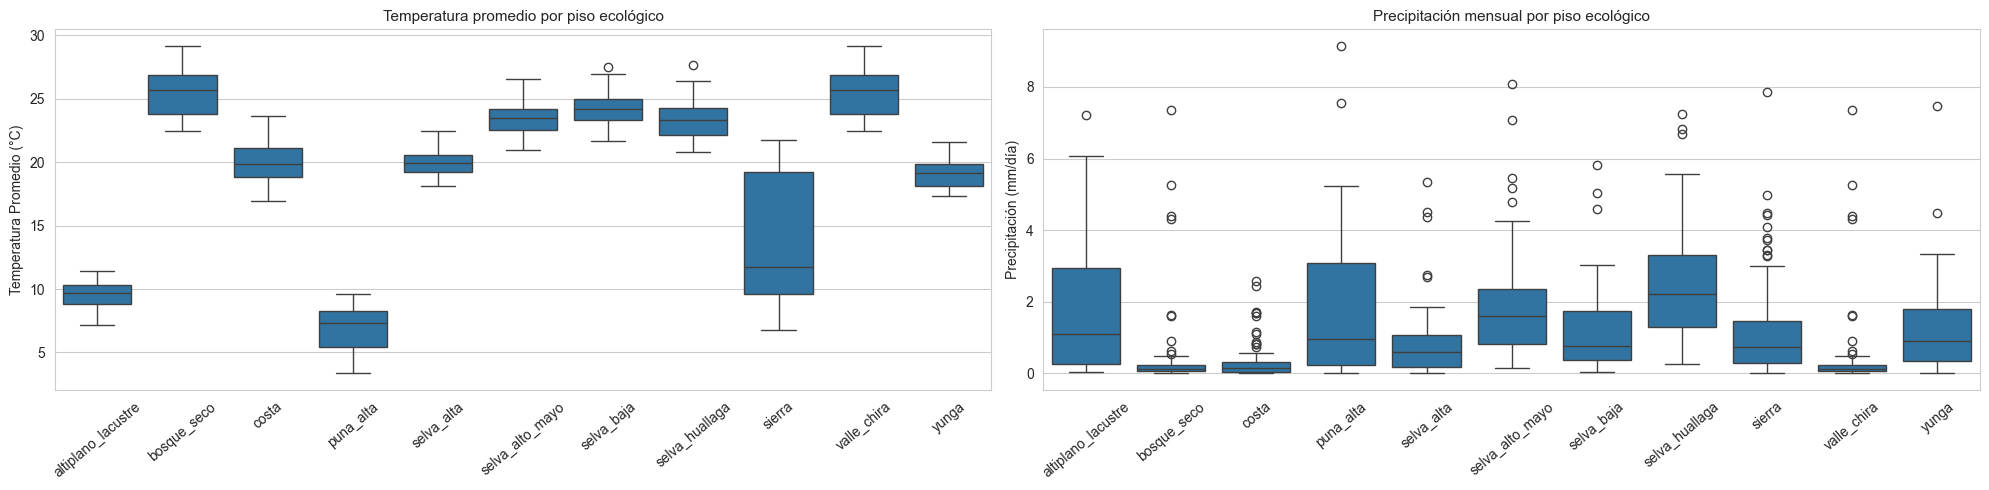

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Temperatura
sns.boxplot(data=df, x='piso', y='t2m', ax=axes[0], 
            order=sorted(df['piso'].unique()))
axes[0].set_title('Temperatura promedio por piso ecológico')
axes[0].set_xlabel('')
axes[0].set_ylabel('Temperatura Promedio (°C)')
axes[0].tick_params(axis='x', rotation=40)

# Precipitación
sns.boxplot(data=df, x='piso', y='prectotcorr', ax=axes[1],
            order=sorted(df['piso'].unique()))
axes[1].set_title('Precipitación mensual por piso ecológico')
axes[1].set_xlabel('')
axes[1].set_ylabel('Precipitación (mm/día)')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

## 4. Validación del evento de sequía 2022-2023 en Puno

Vamos a verificar visualmente que el dataset captura correctamente la sequía altoandina, comparando producción de Puno con sus variables climáticas año por año.

Puno - resumen anual:
              piso  anio  produccion  precip  gwetroot   t2m
altiplano_lacustre  2020  1663477.73    1.69      0.46  9.40
altiplano_lacustre  2021  1293836.01    1.99      0.47  9.23
altiplano_lacustre  2022   836902.66    1.36      0.45  9.32
altiplano_lacustre  2023  1729968.93    2.06      0.44  9.89
altiplano_lacustre  2024  2303230.65    1.49      0.44 10.22
altiplano_lacustre  2025  2357904.03    2.08      0.49  9.38
         puna_alta  2020  3492747.32    1.54      0.48  6.82
         puna_alta  2021  2078338.82    2.02      0.48  6.55
         puna_alta  2022  2204236.55    1.34      0.46  6.66
         puna_alta  2023  2107483.70    2.58      0.49  6.98
         puna_alta  2024  5702602.46    1.36      0.46  7.83
         puna_alta  2025  4774695.48    1.82      0.48  6.76


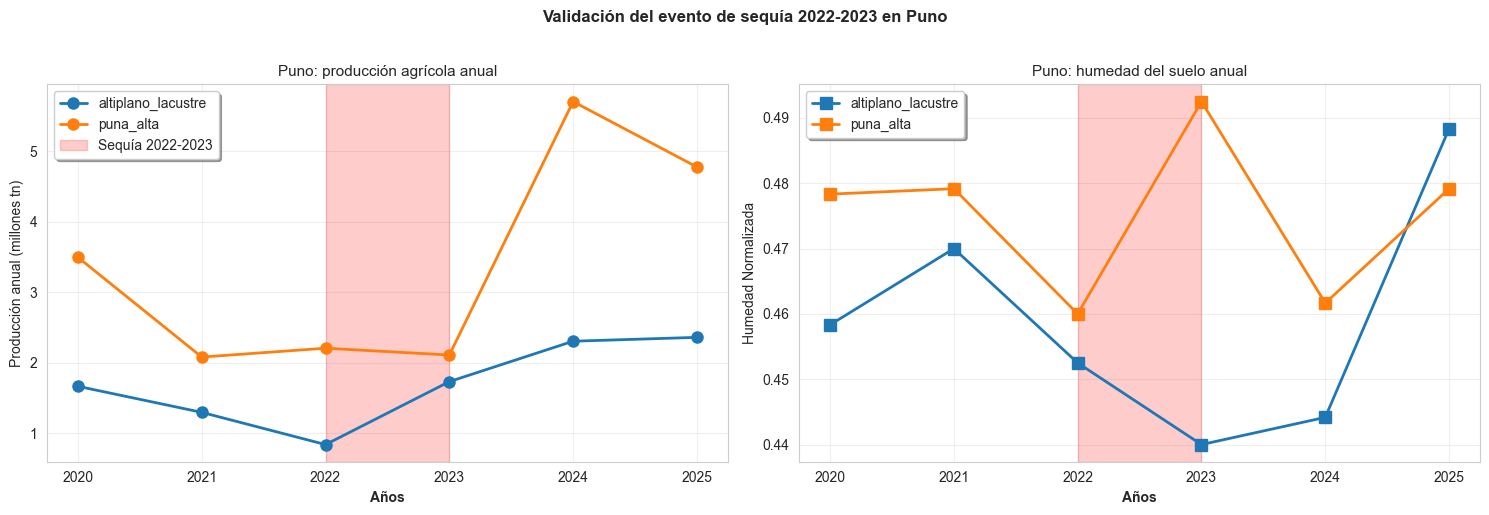


>>> Si la producción cae en 2022 y la humedad del suelo también, el dataset capturó correctamente el evento.


In [113]:
puno = df[df['region']=='Puno'].copy()

# Promedios anuales por piso
puno_anual = (puno.groupby(['piso','anio'])
              .agg(produccion=('produccion_total_piso','sum'),
                   precip=('prectotcorr','mean'),
                   gwetroot=('gwetroot','mean'),
                   t2m=('t2m','mean'))
              .reset_index())

print("Puno - resumen anual:")
print(puno_anual.round(2).to_string(index=False))

# Visualizar producción vs humedad del suelo
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: producción anual
for piso in sorted(puno['piso'].unique()):
    sub = puno_anual[puno_anual['piso']==piso]
    axes[0].plot(sub['anio'], sub['produccion']/1e6, marker='o', linewidth=2, 
                 label=piso, markersize=8)
axes[0].set_title('Puno: producción agrícola anual')
axes[0].set_xlabel('Años', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Producción anual (millones tn)')
axes[0].axvspan(2022, 2023, alpha=0.2, color='red', label='Sequía 2022-2023')
axes[0].legend(shadow=True)
axes[0].grid(True, alpha=0.3)

# Subplot 2: gwetroot anual
for piso in sorted(puno['piso'].unique()):
    sub = puno_anual[puno_anual['piso']==piso]
    axes[1].plot(sub['anio'], sub['gwetroot'], marker='s', linewidth=2,
                 label=piso, markersize=8)
axes[1].set_title('Puno: humedad del suelo anual')
axes[1].set_xlabel('Años', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Humedad Normalizada')
axes[1].axvspan(2022, 2023, alpha=0.2, color='red')
axes[1].legend(shadow=True)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Validación del evento de sequía 2022-2023 en Puno', y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n>>> Si la producción cae en 2022 y la humedad del suelo también, el dataset capturó correctamente el evento.")

In [105]:
# Detalle por cultivo en puna alta, año a año
puno_puna = df_b[(df_b['region']=='Puno') & (df_b['piso_asignado']=='puna_alta')]
print(puno_puna.groupby(['cultivo','anio'])['produccion_mensual']
      .sum().unstack().round(0).head(10))

anio                   2020       2021       2022       2023       2024  \
cultivo                                                                   
avena_forrajera   2176713.0  1204676.0  1553253.0  1255460.0  3897097.0   
cebada_forrajera   374896.0   179214.0   167740.0   175926.0   415113.0   
cebada_grano        29358.0    14063.0    14709.0    14679.0    40610.0   
oca                 29961.0    17891.0    11517.0    21281.0    53330.0   
olluco              18878.0    11189.0     8413.0    10502.0    22458.0   
papa               823323.0   621095.0   434373.0   596114.0  1216827.0   
quinua              39618.0    30211.0    14233.0    33522.0    57168.0   

anio                   2025  
cultivo                      
avena_forrajera   3207704.0  
cebada_forrajera   338947.0  
cebada_grano        31439.0  
oca                 39022.0  
olluco              20358.0  
papa              1098307.0  
quinua              38919.0  


## 5. Correlaciones clima-producción agregadas

Mirada exploratoria: para cada unidad regional, ¿qué variables climáticas correlacionan más con la producción?

**Importante**: estas correlaciones son a nivel agregado. NO implican causalidad, solo asociación estadística. El análisis causal viene en el modelado posterior.

Correlaciones producción - clima por unidad regional:
                              Temp. promedio (°C)  Temp. máxima (°C)  \
unidad                                                                 
Ica - costa                                 0.290              0.245   
Junin - selva_alta                         -0.077             -0.067   
Junin - selva_baja                          0.280              0.180   
Junin - sierra                             -0.265             -0.436   
La Libertad - costa                        -0.118              0.014   
La Libertad - sierra                       -0.022             -0.086   
La Libertad - yunga                        -0.224             -0.088   
Piura - bosque_seco                         0.237              0.131   
Piura - sierra                              0.308              0.122   
Piura - valle_chira                        -0.286             -0.233   
Puno - altiplano_lacustre                   0.062             -0.194   
Puno - pun

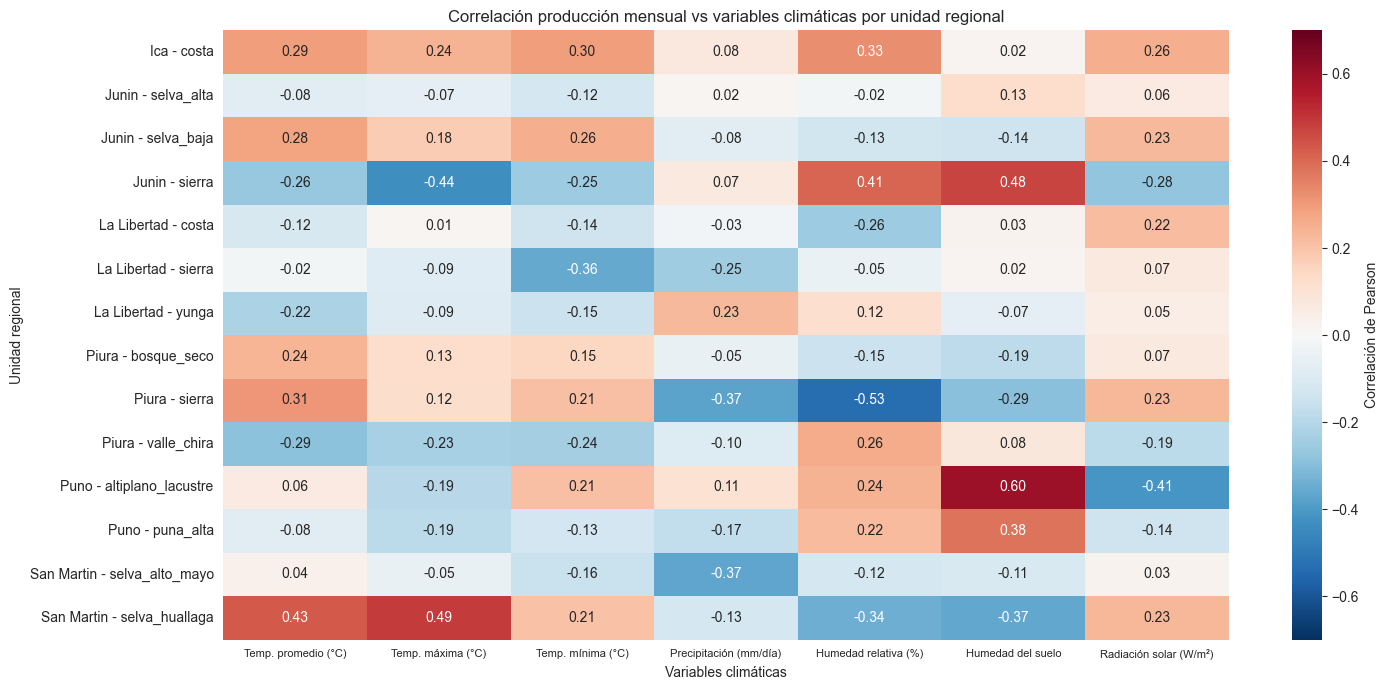


Lectura del heatmap:
- Azul = correlación negativa (más clima → menos producción, o viceversa)
- Rojo = correlación positiva (más clima → más producción)
- Blanco = sin asociación lineal aparente


In [107]:
# Correlación de Pearson entre producción y cada variable climática, por unidad
correlaciones = []
for (region, piso), sub in df.groupby(['region','piso']):
    fila = {'region':region, 'piso':piso}
    for var in vars_clima:
        # Correlación entre producción y la variable, eliminando NaN
        sub_clean = sub[['produccion_total_piso', var]].dropna()
        if len(sub_clean) > 5:
            fila[var] = sub_clean['produccion_total_piso'].corr(sub_clean[var])
        else:
            fila[var] = np.nan
    correlaciones.append(fila)

df_corr = pd.DataFrame(correlaciones)
df_corr['unidad'] = df_corr['region'] + ' - ' + df_corr['piso']
df_corr_plot = df_corr.set_index('unidad')[vars_clima].rename(columns=LABELS_CLIMA)

print("Correlaciones producción - clima por unidad regional:")
print(df_corr_plot.round(3))

# Heatmap de correlaciones
fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(df_corr_plot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.7, vmax=0.7, ax=ax, cbar_kws={'label':'Correlación de Pearson'})
ax.set_title('Correlación producción mensual vs variables climáticas por unidad regional', fontsize=12)
ax.set_xlabel('Variables climáticas')
ax.set_ylabel('Unidad regional')
plt.xticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print("\nLectura del heatmap:")
print("- Azul = correlación negativa (más clima → menos producción, o viceversa)")
print("- Rojo = correlación positiva (más clima → más producción)")
print("- Blanco = sin asociación lineal aparente")

## 6. Conclusiones del EDA del Análisis A

Algunas observaciones que vale documentar (estas son **hipótesis exploratorias**, no conclusiones causales):

| Hallazgo | Cómo se ve en el dataset | Para qué sirve |
|---|---|---|
| Diversidad ecológica capturada | Los 14 pisos muestran climas claramente distintos en los boxplots | Valida la decisión metodológica de la Forma 3 mixta |
| Estacionalidad clara por piso | Los heatmaps muestran ventanas de cosecha bien definidas | Insumo para análisis de campañas y predicción |
| Sequía 2022-2023 en Puno | Caída de producción correlacionada con humedad de suelo baja | Caso de validación empírica |
| Volúmenes muy distintos entre pisos | La Libertad costa concentra grandes volúmenes vs pisos andinos | Justifica análisis separado por piso |
| Correlaciones clima-producción heterogéneas | Algunas unidades muestran asociaciones fuertes, otras casi nulas | Apunta a futuras hipótesis específicas |

**Próximo paso**: notebook 5 (EDA del Análisis B por cultivo). Ahí vamos a desagregar por cultivo y ver qué cultivos específicos son más sensibles al clima.